*Importing Necessary Libraries*

In [1]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Flatten
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.losses import CategoricalCrossentropy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

*Loading Dataset*

In [2]:
train = r'data\train'

# Image data loading
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train,
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(224, 224),
    shuffle=True,
    seed=24,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=True,
    crop_to_aspect_ratio=False,
)

Found 8869 files belonging to 6 classes.


In [3]:
val=r'data\test'

*Data Augmentation*

In [4]:
# Use the Image Data Generator to import the images from the dataset
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale = 1./255,
                                   shear_range = 0.2,
                                   zoom_range = 0.2,
                                   horizontal_flip = True)

val_datagen = ImageDataGenerator(rescale = 1./255,
                                  shear_range = 0.2,
                                   zoom_range = 0.2,
                                   horizontal_flip = True)

In [5]:
# Make sure you provide the same target size as initialied for the image size
train_set = train_datagen.flow_from_directory(train,
                                                 target_size = (224, 224),
                                                 batch_size = 32,
                                                 class_mode = 'categorical')

Found 8869 images belonging to 6 classes.


In [6]:
val_set = val_datagen.flow_from_directory(val,
                                            target_size = (224, 224),
                                            batch_size = 32,
                                            class_mode = 'categorical')

Found 4590 images belonging to 6 classes.


*Dataset's Class*

In [7]:
train_set.class_indices

{'Left Bundle Branch Block': 0,
 'Normal': 1,
 'Premature Atrial Contraction': 2,
 'Premature Ventricular Contractions': 3,
 'Right Bundle Branch Block': 4,
 'Ventricular Fibrillation': 5}

*Visualization*

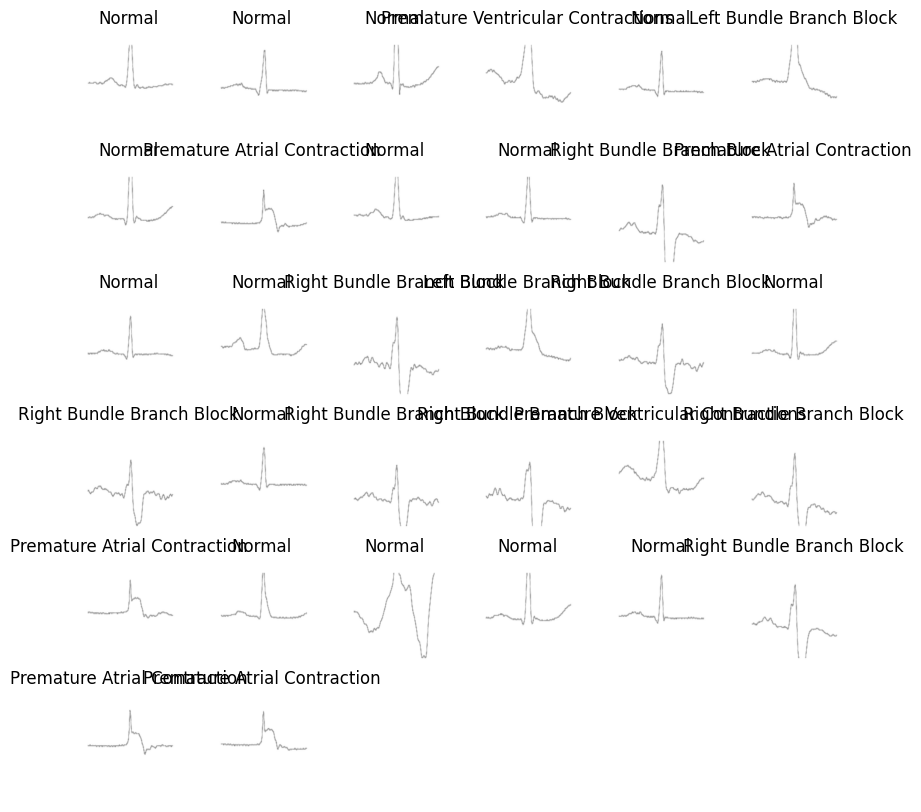

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
class_names = train_ds.class_names

for images, labels in train_ds.take(2):
    for i in range(32):
        ax = plt.subplot(6, 6, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        
        # Extract the class label from the one-hot encoded array
        class_label_index = int(np.argmax(labels[i]))
        plt.title(class_names[class_label_index])
        
        plt.axis("off")

plt.show()

*Grey scale Image Classification*

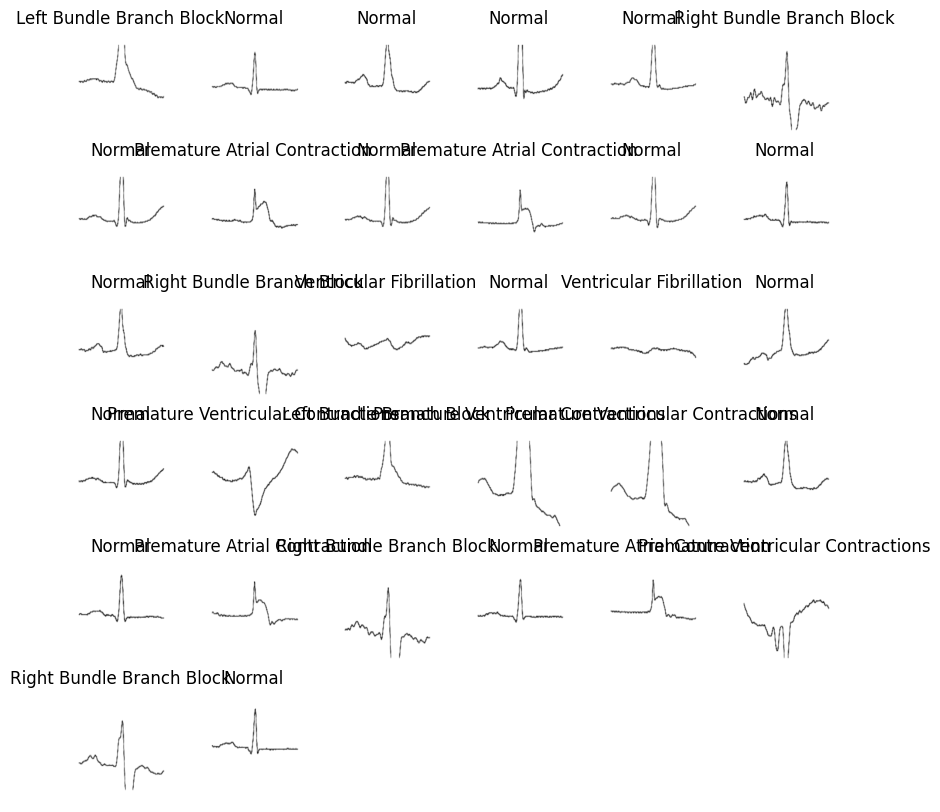

In [9]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 10))
class_names = train_ds.class_names

for images, labels in train_ds.take(2):
    for i in range(32):
        ax = plt.subplot(6, 6, i + 1)
        
        # Convert RGB image to grayscale
        grayscale_image = np.dot(images[i].numpy(), [0.2989, 0.5870, 0.1140])
        plt.imshow(grayscale_image, cmap='gray')
        
        # Extract the class label from the one-hot encoded array
        class_label_index = int(np.argmax(labels[i]))
        plt.title(class_names[class_label_index])
        
        plt.axis("off")

plt.show()

*Model Architecture*

In [10]:
# Load pre-trained Mobilnetnet model
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the convolutional layers
for layer in base_model.layers:
    layer.trainable = False

model = Sequential([
    base_model,
    Flatten(),
    Dense(6, activation='softmax')
])

# Compile the model
model.compile(
    optimizer='adam',
    loss=CategoricalCrossentropy(),
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 62720)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │       376,326 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,634,310 (10.05 MB)

 Trainable params: 376,326 (1.44 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

*Model Training*

In [11]:
# Train the model
history = model.fit(
    train_set,
    validation_data=val_set,
    epochs=5
)

e:\codebook\Deep Learning\env_name\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
278/278 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8878 - loss: 1.6114

e:\codebook\Deep Learning\env_name\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


278/278 ━━━━━━━━━━━━━━━━━━━━ 863s 3s/step - accuracy: 0.8880 - loss: 1.6083 - val_accuracy: 0.8564 - val_loss: 2.9501
Epoch 2/5
278/278 ━━━━━━━━━━━━━━━━━━━━ 838s 3s/step - accuracy: 0.9774 - loss: 0.2689 - val_accuracy: 0.8534 - val_loss: 3.4355
Epoch 3/5
278/278 ━━━━━━━━━━━━━━━━━━━━ 674s 2s/step - accuracy: 0.9780 - loss: 0.3589 - val_accuracy: 0.9105 - val_loss: 3.8355
Epoch 4/5
278/278 ━━━━━━━━━━━━━━━━━━━━ 574s 2s/step - accuracy: 0.9830 - loss: 0.2905 - val_accuracy: 0.9209 - val_loss: 2.8855
Epoch 5/5
278/278 ━━━━━━━━━━━━━━━━━━━━ 538s 2s/step - accuracy: 0.9872 - loss: 0.2290 - val_accuracy: 0.9115 - val_loss: 5.1193


*Model Evaluation*

In [12]:
model.evaluate(val_set)

144/144 ━━━━━━━━━━━━━━━━━━━━ 163s 1s/step - accuracy: 0.9109 - loss: 5.2240


[5.107827663421631, 0.9122004508972168]

*Visualizing Loss and Accuracy*

C:\Users\Admin\AppData\Local\Temp\ipykernel_3168\1006133107.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


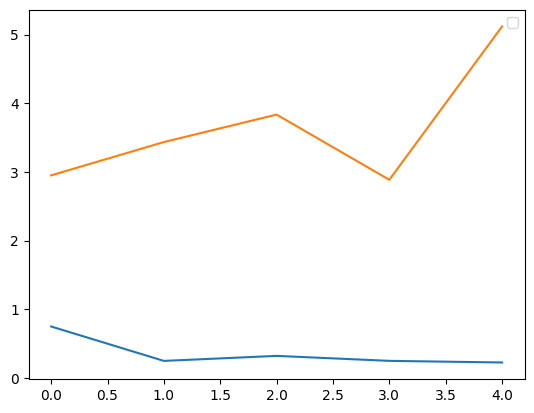

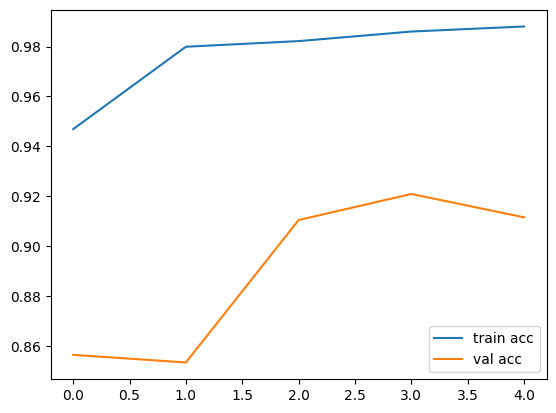

In [13]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend()
plt.show()

# plot the accuracy
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()

*Final Accuracy*

In [14]:
# Print the final training and validation accuracy
final_train_accuracy = history.history['accuracy'][-1]
final_val_accuracy = history.history['val_accuracy'][-1]

print("Final Accuracy:", final_train_accuracy)
print("Final Validation Accuracy:", final_val_accuracy)

Final Accuracy: 0.988048255443573
Final Validation Accuracy: 0.9115468263626099


*Saving Model*

In [15]:
model.save('mobilnet_model.h5')

*User's Prediction*

In [20]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.densenet import preprocess_input

import numpy as np

# Assuming 'model' is already defined
model = load_model('mobilnet_model.h5')



# Dictionary mapping class indices to class labels
class_dict = {
    0:'Left Bundle Branch Block',
    1:'Normal',
    2:'Premature Atrial Contraction',
    3:'Premature Ventricular Contractions',
    4:'Right Bundle Branch Block',
    5:'Ventricular Fibrillation'
}

image_path = r'data\test\Normal\fig_2114.png'
image = load_img(image_path, target_size=(224, 224))
img = np.array(image)
img = preprocess_input(img)
img = img.reshape(1, 224, 224, 3)

prediction = model.predict(img)

# Get the predicted class index
predicted_class_index = np.argmax(prediction)

# Get the corresponding class label
predicted_class_label = class_dict[predicted_class_index]

# Print the predicted class label
print(f"The predicted class is: {predicted_class_label}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
The predicted class is: Normal
